# Load deps

In [ ]:
# !pip install -q torcheval

In [ ]:
# # if src modules imported
# from google.colab import drive
# drive.mount('/content/drive')
# import sys
# app_path = '/content/drive/MyDrive/Projects/miniSD'
# sys.path.append(app_path)

In [ ]:
import torch,timm,torchvision
import torch.nn.functional as F
from torchvision import transforms
from torch import tensor,nn
from torch.utils.data import DataLoader

from src.utils import store_attr
from src.conv import def_device

from src.datasets import show_image, show_images, DataLoaders
from src.learner import Learner, TrainCB, ProgressCB, MetricsCB, DeviceCB, Callback, to_cpu

In [ ]:
#|export --> utils.net
import urllib, json
from urllib.error import HTTPError
from urllib.parse import urlencode, urlparse, urlunparse
from urllib.request import Request


url_default_headers = {
    "Accept":
    "text/html,application/xhtml+xml,application/xml;q=0.9,image/avif,image/webp,image/apng,*/*;q=0.8,application/signed-exchange;v=b3;q=0.9",
    "Accept-Language": "en-US,en;q=0.9",
    "Cache-Control": "max-age=0",
    "Sec-Fetch-Dest": "document",
    "Sec-Fetch-Mode": "navigate",
    "Sec-Fetch-Site": "none",
    "Sec-Fetch-User": "?1",
    "Upgrade-Insecure-Requests": "1",
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/87.0.4280.88 Safari/537.36"
}

class _SafeRedirectHandler(urllib.request.HTTPRedirectHandler):
    def redirect_request(self, req, fp, code, msg, headers, newurl):
        if code in (307, 308):
            new_req = Request(newurl, data=req.data, method=req.get_method())
            for k,v in req.headers.items(): new_req.add_header(k, v)
        else: new_req = super().redirect_request(req, fp, code, msg, headers, newurl)
        if new_req and urlparse(newurl).netloc != urlparse(req.full_url).netloc: new_req.remove_header('Authorization')
        return new_req

def urlopener():
    _opener = urllib.request.build_opener(_SafeRedirectHandler)
    _opener.addheaders = list(url_default_headers.items())
    return _opener


def urlquote(url):
    "Update url's path with `urllib.parse.quote`"
    subdelims = "!$&'()*+,;="
    gendelims = ":?#[]@"
    safe = subdelims+gendelims+"%/"
    p = list(urlparse(url))
    p[2] = urllib.parse.quote(p[2], safe=safe)
    for i in range(3,6): p[i] = urllib.parse.quote(p[i], safe=safe)
    return urlunparse(p)

def urlwrap(url, data=None, headers=None):
    "Wrap `url` in a urllib `Request` with `urlquote`"
    return url if isinstance(url,Request) else Request(urlquote(url), data=data, headers=headers or {})

def urlopen(url, data=None, headers=None, timeout=None, **kwargs):
    "Like `urllib.request.urlopen`, but first `urlwrap` the `url`, and encode `data`"
    if kwargs and not data: data=kwargs
    if data is not None:
        if not isinstance(data, (str,bytes)): data = urlencode(data)
        if not isinstance(data, bytes): data = data.encode('ascii')
    try: return urlopener().open(urlwrap(url, data=data, headers=headers), timeout=timeout)
    except HTTPError as e: 
        e.msg += f"\n====Error Body====\n{e.read().decode(errors='ignore')}"
        raise


def urlread(url, data=None, headers=None, decode=True, return_json=False, return_headers=False, timeout=None, **kwargs):
    "Retrieve `url`, using `data` dict or `kwargs` to `POST` if present"
    try:
        with urlopen(url, data=data, headers=headers, timeout=timeout, **kwargs) as u: res,hdrs = u.read(),u.headers
    except HTTPError as e:
        e.msg += f"\n====Error Body====\n{e.read().decode(errors='ignore')}"
        raise

    if decode: res = res.decode()
    if return_json: res = json.loads(res)
    return (res,dict(hdrs)) if return_headers else res

# Load and preview Images

In [ ]:
face_url = "https://images.pexels.com/photos/2690323/pexels-photo-2690323.jpeg?w=256"
spiderweb_url = "https://images.pexels.com/photos/34225/spider-web-with-water-beads-network-dewdrop.jpg?w=256"

In [ ]:
def download_image(url):
    imgb = urlread(url, decode=False)
    return torchvision.io\
        .decode_image(tensor(list(imgb), dtype=torch.uint8))\
        .float()/255.

content_im = download_image(face_url).to(def_device)
print('content_im.shape:', content_im.shape)
show_image(content_im);
print(f"image bounds: min = {content_im.min()} | max = {content_im.max()}") # Check bounds

# Optimizing Images

- We're using dummy Model and Dataset objects in order to use our current training tools
- But optimizing an image instead of a model

In [ ]:
class LengthDataset():
    def __init__(self, length=1): self.length=length
    def __len__(self): return self.length
    def __getitem__(self, idx): return 0,0

def get_dummy_dls(length=100):
    return DataLoaders(
        DataLoader(LengthDataset(length), batch_size=1), # Train
        DataLoader(LengthDataset(1), batch_size=1)       # Valid (length 1)
    )

class TensorModel(nn.Module):
    def __init__(self, t):
        super().__init__()
        self.t = nn.Parameter(t.clone())
    def forward(self, x=0): return self.t

class ImageOptCB(TrainCB):
    def predict(self, learn): learn.preds = learn.model()
    def get_loss(self, learn): learn.loss = learn.loss_func(learn.preds)

def loss_fn_mse(im):
    return F.mse_loss(im, content_im)

In [ ]:
model = TensorModel(torch.rand_like(content_im))
print([p.shape for p in model.parameters()])
print("====================")
show_image(model());

In [ ]:
model = TensorModel(torch.rand_like(content_im))
cbs = [ImageOptCB(), ProgressCB(), MetricsCB(), DeviceCB()]
learn = Learner(
    model,
    get_dummy_dls(100),
    loss_fn_mse,
    lr=1e-2,
    cbs=cbs,
    opt_func=torch.optim.Adam
)
learn.fit(1)

# Result (left) vs target image (right):
show_images([learn.model().clip(0, 1), content_im]);

## Viewing optimization progress

- It would be great if we could see what is happening over time.
- We could save individual images and turn them into a video
- but for quick feedback we can also log images every few iterations and display them in a grid in `after_fit`

In [ ]:
class ImageLogCB(Callback):
    order = ProgressCB.order + 1
    def __init__(self, log_every=10):
        store_attr()
        self.images=[]
        self.i=0
    def after_batch(self, learn): 
        if self.i%self.log_every == 0:
            self.images.append(to_cpu(learn.preds.clip(0, 1)))
        self.i += 1
    def after_fit(self, learn): show_images(self.images)

In [ ]:
model = TensorModel(torch.rand_like(content_im))
learn = Learner(model, get_dummy_dls(150), loss_fn_mse, 
                lr=1e-2, cbs=cbs, opt_func=torch.optim.Adam)
learn.fit(1, cbs=[ImageLogCB(30)])

# Getting Features from VGG16

We're going to peek inside a small CNN and extract the outputs of different layers.

## Load VGG network

<img src="https://neurohive.io/wp-content/uploads/2018/11/vgg16-1-e1542731207177.png" alt="vgg diag" width="600">

In [ ]:
print(timm.list_models('*vgg*'))
vgg16 = timm.create_model('vgg16', pretrained=True).to(def_device).features
# we're getting layers up to the last max pool layer by using the `features` property
vgg16

## Normalize Images

- This model expacts images **normalized** with the same stats as those used during training,
    - which in this case requires the stats of the ImageNet dataset.
- Previously we were working with single-channel images, and so normalizing was pretty straightforward.
- With three channels, we need to think a bit more about shapes and boradcasting rules.

In [ ]:
imagenet_mean = tensor([0.485, 0.456, 0.406])
imagenet_std = tensor([0.229, 0.224, 0.225])
print(imagenet_mean.shape)
print(content_im.shape)
print(imagenet_mean[:,None,None].shape)

In [ ]:
def normalize(im):
    imagenet_mean = tensor([0.485, 0.456, 0.406])[:,None,None].to(im.device)
    imagenet_std = tensor([0.229, 0.224, 0.225])[:,None,None].to(im.device)
    return (im - imagenet_mean) / imagenet_std

normed_im = normalize(content_im)
print(f"min = {normed_im.min()} | max = {normed_im.max()} | channel means = {normed_im.mean(dim=(1, 2))}")

In [ ]:
# And with torchvision transforms:
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
normalize(content_im).min(), normalize(content_im).max()

## Get intermediate representations

- We want to feed some data through the network, storing their outputs of different layers. Here's one way to do this:

In [ ]:
def calc_features(imgs, target_layers=(18, 25)):
    # using tuple instead of list for the default values of an argument
    # TODO: using list which is mutable would cause some errors. why is that?
    x = normalize(imgs)
    feats = []
    for i, layer in enumerate(vgg16[:max(target_layers)+1]):
        x = layer(x)
        if i in target_layers:
            feats.append(x.clone())
    return feats


# Testing it out to see the shapes of the resulting feature maps:
feats = calc_features(content_im)
[f.shape for f in feats]

# TODO: try to do this using hooks?

### What's the point?

- Look at https://distill.pub/2017/feature-visualization/ talking about how deep CNNs 'learn' to classify images.
- Early layers tend to capture gradients and textures, while later layers tend towards more complex types of feature.
- We're going to exploit this hierarchy for artistic purposes, but being able to choose what kind of feature you'd like to use when comparing images has a number of other useful applications. 

# Optimizing an Image with Content Loss

To start with, let's try optimizing an image by comparing it's features (from two later layers) with those from the target image. If our theory is right, we should see the structure of the target emerge from the noise without necessarily seeing a perfect re-production of the target like we did in the previous MSE loss example.

In [ ]:
class ContentLossToTarget():
    def __init__(self, target_im, target_layers=(18, 25)):
        store_attr()
        with torch.no_grad():
            self.target_features = calc_features(target_im, target_layers)
    def __call__(self, input_im): 
        return sum(
            (f1-f2).pow(2).mean()
            for f1, f2 in zip(
                calc_features(input_im, self.target_layers),
                self.target_features
            )
        )

In [ ]:
loss_function_perceptual = ContentLossToTarget(content_im)
model = TensorModel(torch.rand_like(content_im))
learn = Learner(model, get_dummy_dls(150), loss_function_perceptual, 
                lr=1e-2, cbs=cbs, opt_func=torch.optim.Adam)
learn.fit(1, cbs=[ImageLogCB(log_every=30)])

**Choosing the layers determines the kind of features that are important:**

In [ ]:
loss_function_perceptual = ContentLossToTarget(content_im, target_layers=(1, 6))
model = TensorModel(torch.rand_like(content_im))
learn = Learner(model, get_dummy_dls(150), loss_function_perceptual, 
                lr=1e-2, cbs=cbs, opt_func=torch.optim.Adam)
learn.fit(1, cbs=[ImageLogCB(log_every=30)])

# Style Loss with Gram Matrix

So, we know how to extract feature maps. The next thing we'd like to do is find a way to capture the **style** of an input image, based on those early layers and the kinds of textural feature that they learn. Unfortunately, we can't just compare the feature maps from some early layers since these 'maps' encode information **spatially** - which we don't want!

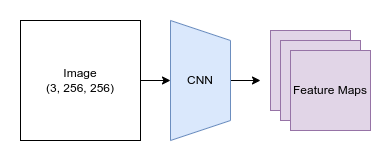

So, we need a way to measure what **kinds** of style features are present, and ideally which kinds occur together, without worrying about **where** these features occur in the image. 

Enter something called the Gram Matrix. The idea here is that we'll measure the **correlation** between features. Given a feature map with `f` features in an `h` x `w` grid, we'll flatten out the spatial component and then for every feature we'll take the dot product of that row with itself, giving an `f` x `f` matrix as the result. Each entry in this matrix quantifies how correlated the relevant pair of features are and how frequently they occur - exactly what we want. In this diagram each feature is represented as a colored dot.

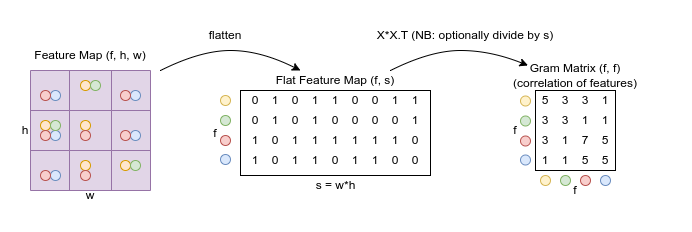

Re-creating the diagram operations in code:

In [ ]:
t = tensor([[0, 1, 0, 1, 1, 0, 0, 1, 1],
            [0, 1, 0, 1, 0, 0, 0, 0, 1],
            [1, 0, 1, 1, 1, 1, 1, 1, 0],
            [1, 0, 1, 1, 0, 1, 1, 0, 0]])
print(torch.einsum('fs, gs -> fg', t, t))
print("="*50)
print(t.matmul(t.T)) # Alternate approach

### Trying it out

In [ ]:
style_im = download_image(spiderweb_url).to(def_device)
show_image(style_im);

In [ ]:
def calc_grams(img, target_layers=(1, 6, 11, 18, 25)):
    return [
        torch.einsum('chw, dhw -> cd', x, x) / (x.shape[-2]*x.shape[-1])
        # 'bchw, bdhw -> bcd' if batched. don't we pass batched here???
        # we need normalization because corr values are larger for larger H,W
        for x in calc_features(img, target_layers)
    ]
style_grams = calc_grams(style_im)
display([g.shape for g in style_grams])

In [ ]:
class StyleLossToTarget():
    def __init__(self, target_im, target_layers=(1, 6, 11, 18, 25)):
        store_attr()
        with torch.no_grad(): self.target_grams = calc_grams(target_im, target_layers)
    def __call__(self, input_im): 
        return sum(
            (f1-f2).pow(2).mean()
            for f1, f2 in zip(
                calc_grams(input_im, self.target_layers),
                self.target_grams
            )
        )

style_loss = StyleLossToTarget(style_im)
style_loss(content_im)

# Style + Content Transfer

- Start from content image

In [ ]:
model = TensorModel(content_im)
style_loss = StyleLossToTarget(style_im)
content_loss = ContentLossToTarget(content_im)
def combined_loss(x):
    return style_loss(x) + content_loss(x)
learn = Learner(
    model,
    get_dummy_dls(150),
    combined_loss,
    lr=1e-2,
    cbs=cbs,
    opt_func=torch.optim.Adam
)
learn.fit(1, cbs=[ImageLogCB(30)])
show_image(learn.model().clip(0, 1)); # View the final result

- And trying with random starting image, weighting the style loss lower, using different layers:

In [ ]:
model = TensorModel(torch.rand_like(content_im))
style_loss = StyleLossToTarget(style_im)
content_loss = ContentLossToTarget(content_im, target_layers=(6, 18, 25))
def combined_loss(x):
    return style_loss(x) * 0.2 + content_loss(x)
learn = Learner(model, get_dummy_dls(300), combined_loss, lr=5e-2, cbs=cbs, opt_func=torch.optim.Adam)
learn.fit(1, cbs=[ImageLogCB(60)])

## For Comparison: non-miniai version

In [ ]:
# The image to be optimized
im = torch.rand(3, 256, 256).to(def_device)
im.requires_grad = True

# Set up the optimizer
opt = torch.optim.Adam([im], lr=5e-2)

# Define the loss function
style_loss = StyleLossToTarget(style_im)
content_loss = ContentLossToTarget(content_im, target_layers=[6, 18, 25])
def combined_loss(x):
    return style_loss(x) * 0.2 + content_loss(x)

# Optimization loop
for i in range(300):
    loss = combined_loss(im)
    loss.backward()
    opt.step()
    opt.zero_grad()
# Show the result
show_image(im.clip(0, 1));